In [18]:
import sys
sys.path.append('..')
import os

from config import TICKERS, START, END
from src.data_loader import fetch_prices
from src.returns import *
from src.stats import *
import matplotlib.pyplot as plt

BASE_DIR = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(PROCESSED_DIR, exist_ok=True)

In [19]:
df = fetch_prices(TICKERS,START,END)
df.head()

Saved data to: d:\AQUA\Projects\Financial_Data_Explorer\Multiple_Stocks\data\raw\prices.csv


Ticker,AAPL,GS,JNJ,JPM,KO,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-02,37.469204,144.753738,103.791008,80.836510,37.341599,94.193161,3.373053,20.674667,27.913776,49.664757
2019-01-03,33.737000,142.633240,102.141716,79.687675,37.110859,90.727966,3.169262,20.024000,27.770231,48.902206
2019-01-04,35.177216,147.294861,103.855980,82.625404,37.850830,94.947655,3.372308,21.179333,27.943682,50.705212
2019-01-07,35.098919,148.111099,103.189781,82.682846,37.357510,95.068764,3.550842,22.330667,28.272636,50.968899
2019-01-08,35.767994,147.564133,105.586494,82.526947,37.779228,95.758057,3.462443,22.356667,28.470020,51.339485


In [20]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   GS      1258 non-null   float64
 2   JNJ     1258 non-null   float64
 3   JPM     1258 non-null   float64
 4   KO      1258 non-null   float64
 5   MSFT    1258 non-null   float64
 6   NVDA    1258 non-null   float64
 7   TSLA    1258 non-null   float64
 8   WMT     1258 non-null   float64
 9   XOM     1258 non-null   float64
dtypes: float64(10)
memory usage: 108.1 KB
None
Ticker         AAPL           GS          JNJ          JPM           KO  \
count   1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean     120.208070   258.181052   135.695853   114.881933    47.712673   
std       46.294312    71.377171    16.786884    22.331146     6.624233   
min       33.737000   116.619820    93.433510    66.763306    31.103397   
25%     

In [21]:
returns = log_ret(df)
returns.head()

Ticker,AAPL,GS,JNJ,JPM,KO,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-03,-0.104924,-0.014757,-0.016018,-0.014314,-0.006198,-0.037482,-0.062319,-0.031978,-0.005156,-0.015473
2019-01-04,0.041803,0.032160,0.016644,0.036202,0.019743,0.045460,0.062099,0.056094,0.006226,0.036206
2019-01-07,-0.002228,0.005526,-0.006435,0.000695,-0.013119,0.001275,0.051587,0.052935,0.011703,0.005187
2019-01-08,0.018883,-0.003700,0.022961,-0.001887,0.011225,0.007224,-0.025210,0.001164,0.006957,0.007245
2019-01-09,0.016839,0.006253,-0.007957,-0.001692,-0.019352,0.014198,0.019476,0.009438,-0.003262,0.005261


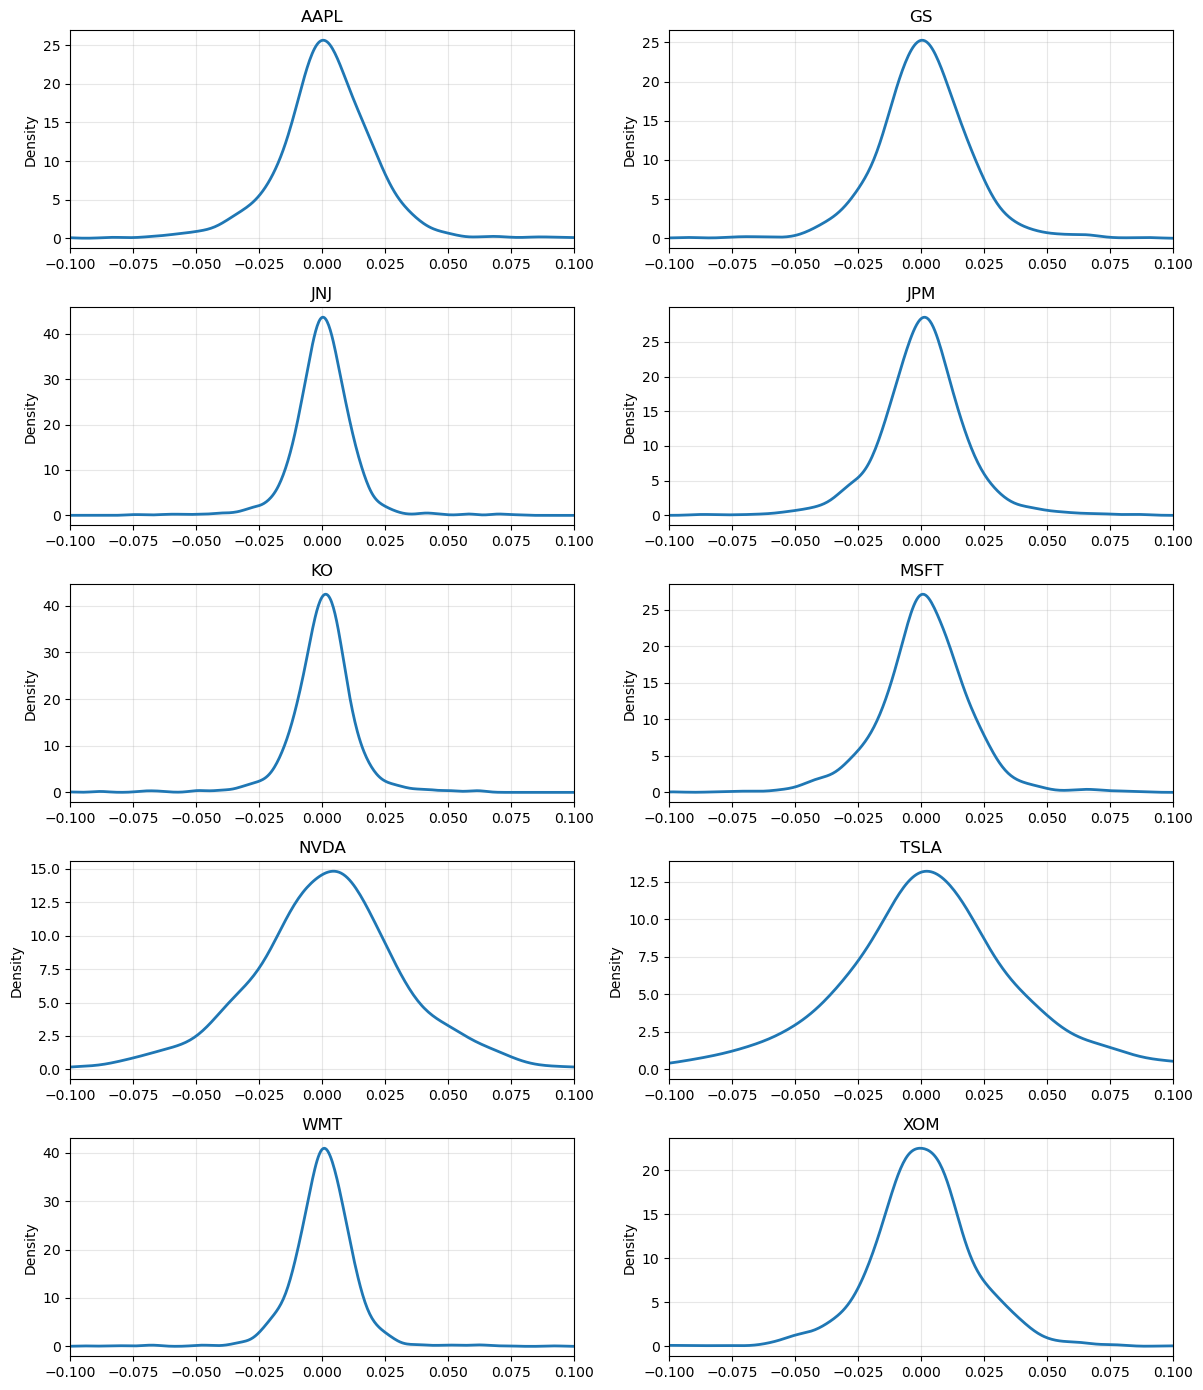

In [22]:
fig, axes = plt.subplots(5, 2, figsize=(12, 14))

for ax, col in zip(axes.ravel(), returns.columns):
    returns[col].plot(kind="kde", ax=ax, linewidth=2)
    ax.set_title(col)
    ax.set_xlim(-0.1, 0.1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

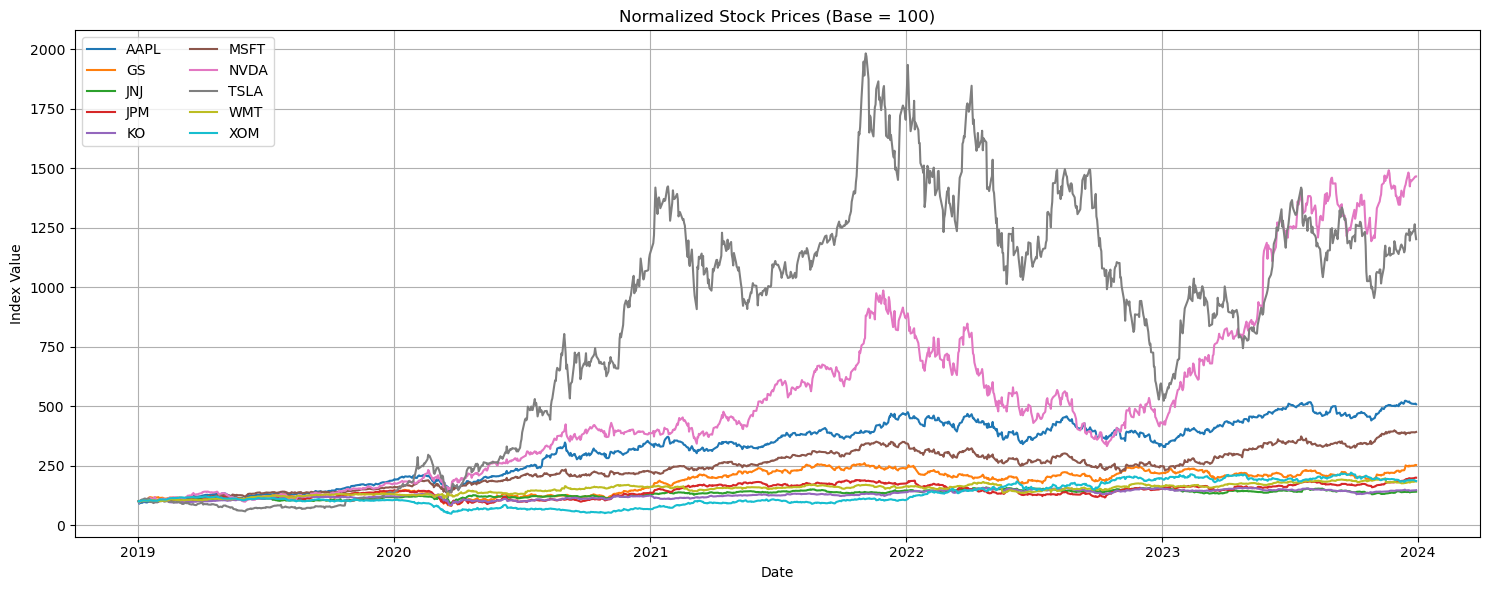

In [23]:
normalized = df / df.iloc[0] * 100

plt.figure(figsize=(15, 6))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title("Normalized Stock Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend(loc="upper left", ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
weekly_ret = week_ret(df)
monthly_ret = month_ret(df)
yearly_ret =year_ret(df)


returns.to_csv(os.path.join(PROCESSED_DIR, "daily_log_returns.csv"))
weekly_ret.to_csv(os.path.join(PROCESSED_DIR, "weekly_returns.csv"))
monthly_ret.to_csv(os.path.join(PROCESSED_DIR, "monthly_returns.csv"))
yearly_ret.to_csv(os.path.join(PROCESSED_DIR, "yearly_returns.csv"))

In [25]:
stats = descriptive(df).sort_values('vol_annual', ascending=False)
stats

,mean_daily,mean_annual,std_daily,vol_annual,skewness,excess_kurtosis,min,max,sharpe_naive
Ticker,,,,,,,,,
TSLA,170.8875,43063.6423,108.3045,1719.2810,-0.1552,-1.2062,11.9313,409.9700,25.0475
MSFT,227.3541,57293.2362,72.0580,1143.8848,-0.1126,-0.9945,90.7280,375.4061,50.0865
GS,258.1811,65061.6252,71.3772,1133.0775,-0.2038,-1.5217,116.6198,377.3182,57.4203
AAPL,120.2081,30292.4336,46.2943,734.8994,-0.3893,-1.1477,33.7370,195.8926,41.2198
XOM,62.9121,15853.8596,23.9805,380.6787,0.3704,-1.1806,23.8236,109.6244,41.6463
JPM,114.8819,28950.2471,22.3311,354.4960,-0.0866,-1.2278,66.7633,161.3232,81.6659
JNJ,135.6959,34195.3549,16.7869,266.4835,-0.3699,-1.1398,93.4335,164.6817,128.3207
NVDA,17.6924,4458.4949,12.4502,197.6401,1.0188,0.2545,3.1693,50.3151,22.5587
KO,47.7127,12023.5935,6.6242,105.1564,-0.0890,-1.2351,31.1034,58.4277,114.3401


In [26]:
risk = risk_analysis(returns)
risk

,Parametric VaR,Historical VaR,Expected Shortfall,Sharpe Ratio,Semi Deviation,Sortino Ratio,Max Drawdown,CAGR,Calmar Ratio
Ticker,,,,,,,,,
AAPL,-0.0321,-0.0312,-0.0473,0.8554,0.0152,1.1413,-0.3518,0.3146,0.8944
GS,-0.0332,-0.0291,-0.0463,0.4144,0.0154,0.5556,-0.4902,0.1410,0.2877
JNJ,-0.0203,-0.0168,-0.0297,0.0914,0.0094,0.1210,-0.2902,0.0496,0.1710
JPM,-0.0324,-0.0286,-0.0453,0.2773,0.0153,0.3637,-0.4730,0.0914,0.1933
KO,-0.0220,-0.0183,-0.0341,0.1252,0.0115,0.1472,-0.3860,0.0551,0.1426
MSFT,-0.0305,-0.0295,-0.0436,0.7332,0.0143,0.9846,-0.4061,0.2547,0.6271
NVDA,-0.0512,-0.0484,-0.0705,0.9478,0.0219,1.4022,-0.7187,0.4998,0.6954
TSLA,-0.0651,-0.0637,-0.0957,0.6929,0.0302,0.9357,-0.7988,0.3322,0.4159
WMT,-0.0224,-0.0190,-0.0317,0.3246,0.0112,0.4023,-0.2679,0.1021,0.3811
